## Project Overview
A machine learning-based tourism market segmentation system using unsupervised clustering and dimensionality reduction techniques. This project leverages **K-Means Clustering with PCA (Principal Component Analysis)** to identify distinct tourist segments based on spending patterns, travel behavior, and demographics, supporting Tanzania's tourism board in strategic market targeting and revenue optimization.

**Industry:** Tanzanian Tourism

In [1]:
#pip install yellowbrick

### IMPORT THE DEPENDENCIES

In [2]:
# Import the needed libraries

# For Data Analysis
import pandas as pd
import numpy as np

# For Data Visiualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Data Pre-Processing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Mavhine Learning and Evaluation
from sklearn.cluster import KMeans # KMeans is for Clustering
from sklearn.decomposition import PCA # PCA is for Dimentionalty Reduction
from yellowbrick.cluster import KElbowVisualizer # To visualize the Elbow Method...

# Calculate Silhouette Score
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

### DATA COLLECTION AND DATA PROCESSING

In [3]:
# Load The Dataset to PandaFrame
Tanzaninan_TC = pd.read_csv('Train.csv')

In [4]:
Tanzaninan_TC.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [5]:
# Check the information of the dataset
Tanzaninan_TC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [6]:
# Check the shape of the dataset
Tanzaninan_TC.shape

(4809, 23)

In [7]:
# Set display option to show all columns
pd.set_option('display.max_columns', None)
Tanzaninan_TC.head(2)

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,No,No,No,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5


In [8]:
# Investigate the statistical values of the numerical columns
Tanzaninan_TC.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


In [9]:
# Investigate the statistical values of the categorical columns
Tanzaninan_TC.describe(exclude='int64')

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
count,4809,4809,4809,3695,4806.000000,4804.000000,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809,4809.000000,4809.000000,4809,4809,4496,4.809000e+03
unique,4809,105,4,5,NaN,NaN,7,9,8,2,2,2,2,2,2,2,2,NaN,NaN,4,2,7,NaN
top,tour_0,UNITED STATES OF AMERICA,25-44,Alone,NaN,NaN,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,NaN,NaN,Cash,Yes,Friendly People,NaN
freq,1,695,2487,1265,NaN,NaN,2840,2259,1913,2570,3357,2602,2748,2919,3319,3259,4079,NaN,NaN,4172,3243,1541,NaN
mean,NaN,NaN,NaN,NaN,0.926758,1.009575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.488043,2.304429,NaN,NaN,NaN,8.114389e+06
std,NaN,NaN,NaN,NaN,1.288242,1.138865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.427624,4.227080,NaN,NaN,NaN,1.222490e+07
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,4.900000e+04
25%,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,NaN,NaN,8.121750e+05
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,0.000000,NaN,NaN,NaN,3.397875e+06
75%,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,4.000000,NaN,NaN,NaN,9.945000e+06


In [10]:
# Check the unique values in each column
{x: len(Tanzaninan_TC[x].unique()) for x in Tanzaninan_TC.columns}

{'ID': 4809,
 'country': 105,
 'age_group': 4,
 'travel_with': 6,
 'total_female': 15,
 'total_male': 15,
 'purpose': 7,
 'main_activity': 9,
 'info_source': 8,
 'tour_arrangement': 2,
 'package_transport_int': 2,
 'package_accomodation': 2,
 'package_food': 2,
 'package_transport_tz': 2,
 'package_sightseeing': 2,
 'package_guided_tour': 2,
 'package_insurance': 2,
 'night_mainland': 64,
 'night_zanzibar': 34,
 'payment_mode': 4,
 'first_trip_tz': 2,
 'most_impressing': 8,
 'total_cost': 1637}

In [11]:
# Check for missing values in the dataset
Tanzaninan_TC.isnull().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
dtype: int64

## UNSUPERVISED ML

### DATA PREPROCESSING
* Data Cleaning
* Encoding The Categorical Variables
* Data Normalization

In [12]:
# Create a copy of the dataset
Tanzaninan_TC_2 = Tanzaninan_TC.copy()

In [13]:
# Drop the missing features in the dataset
Tanzaninan_TC_2.dropna(inplace = True)

In [14]:
# Create a copy of Tanzaninan_TC_2
Tanzaninan_TC_3 = Tanzaninan_TC_2.copy()

### LABEL ENCODING
* Converting Categorical Features to Numerical Features

In [15]:
# Label encoding of the Categorical Features
Cat_feat = (Tanzaninan_TC_2.dtypes == "object")
Cat_feat = list(Cat_feat[Cat_feat].index)

Encoder = LabelEncoder()
for i in Cat_feat:
    Tanzaninan_TC_2[i] = Tanzaninan_TC_2[[i]].apply(Encoder.fit_transform)

In [16]:
# Check the first five rows of the dataset after encoding the categorical features
Tanzaninan_TC_2.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,0,82,2,2,1.0,1.0,1,7,0,0,0,0,0,0,0,0,0,13.0,0.0,0,0,2,674602.5
2,1,92,1,0,0.0,1.0,5,3,0,0,0,0,0,0,0,0,0,1.0,31.0,0,0,1,3315000.0
3,2,92,1,3,1.0,1.0,1,7,5,1,0,1,1,1,1,1,0,11.0,0.0,0,1,2,7790250.0
6,3,76,2,0,0.0,1.0,0,6,0,0,0,0,0,0,0,0,0,9.0,0.0,0,1,2,466140.0
7,4,93,2,2,1.0,1.0,1,7,5,1,1,1,1,1,1,1,1,10.0,3.0,0,1,2,3480750.0


### DATA NORMALIZATION

* I AM USING THE MINMAX SCALER TO NORMALIZE THE DATA

In [17]:
# Drop Redundant Features
Tanzaninan_TC_2.drop(['ID', 'country'], axis = 1, inplace = True)

In [18]:
# Scale The Dataset using the MinMax Scaler
Scaler = MinMaxScaler()
Scaled_Data = Scaler.fit_transform(Tanzaninan_TC_2)
Scaled_Data = pd.DataFrame(Scaled_Data, columns = Tanzaninan_TC_2.columns)

### DIMENTIONALITY REDUCTION USING PCA

In [19]:
# Instabtiate The PCA Algorithym
pca_algo = PCA(n_components = 3)
pca_data = pd.DataFrame(pca_algo.fit_transform(Scaled_Data), columns=(['Dimension_1', 'Dimension_2','Dimension_3']))
pca_data

,Dimension_1,Dimension_2,Dimension_3
0,-1.282541,-0.308373,0.470358
1,-1.416508,-0.118325,0.558398
2,1.194915,-0.682553,-0.315439
3,-1.169032,-0.210630,-0.399154
4,1.638534,-0.118712,0.023333
...,...,...,...
3455,-1.196074,0.392162,-0.498259
3456,-1.352682,-0.268381,0.548946
3457,1.651448,-0.032757,-0.038450
3458,-0.174259,0.827772,0.812367


In [20]:
# PCA Explained
pca_algo.explained_variance_ratio_

array([0.52485363, 0.07951387, 0.06391414])

Text(0.5, 0.92, '3d Visualization of Our New Dimensions')

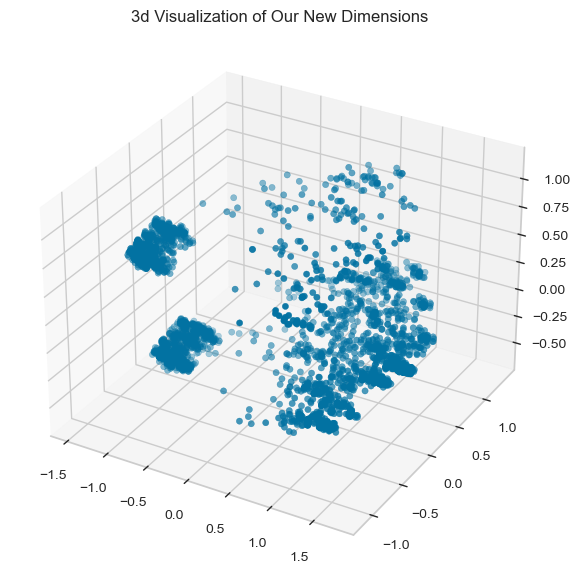

In [21]:
# VISUALIZING THE THREE DATA DIMENSIONS
x = pca_data ['Dimension_1']
y = pca_data ['Dimension_2']
z = pca_data ['Dimension_3']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(x,y,z, marker = "o")
ax.set_title ("3d Visualization of Our New Dimensions")

## CLUSTERING SECTION OF THE PROJECT

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=10))

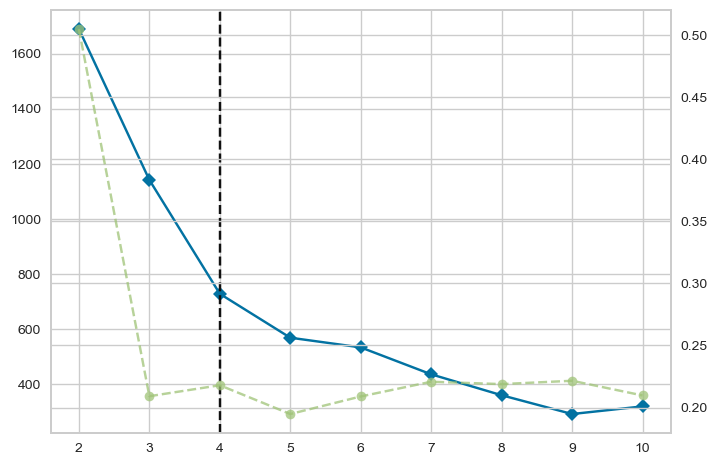

In [22]:
# Visualizing the K-Elbow Method to determine the amount of clusters needed
k_elbow = KElbowVisualizer(estimator = KMeans(), distance_metric='euclidean')
k_elbow.fit(pca_data)

#### From the above visualization, (4) happens to be the optimum number of clusters needed for the unsupervised model.

In [23]:
# Instantiate KMeans Algorythm
K_Means = KMeans(n_clusters = 4, random_state = 1)
Y_Means = K_Means.fit_predict(pca_data)
pca_data['clusters'] = Y_Means
Tanzaninan_TC_3['clusters'] = Y_Means

#### Model Evaluation using the Silhouette Score

In [32]:
# Calculate Silhouette Score
Score = silhouette_score(pca_data, pca_data.clusters, metric = 'euclidean')
print(Score)

0.7183398029598389


#### The Silhouette score is 0.71% which is a very good score.

Text(0.5, 0.92, '3d Visualization of Our Data by their Clusters')

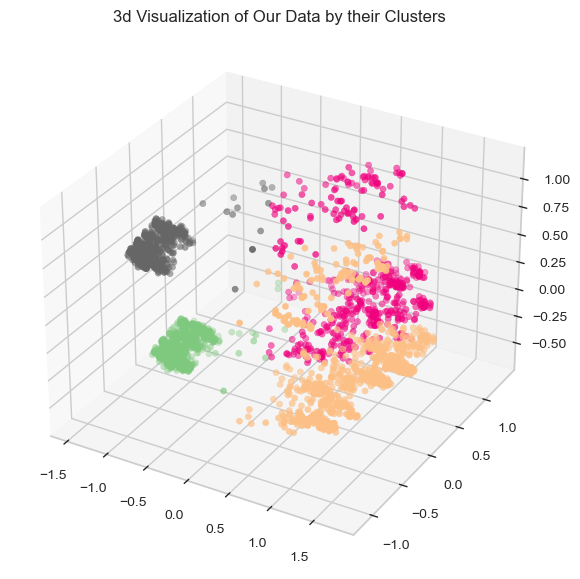

In [25]:
# Plotting The New Data Point
cmap = "Accent"
fig = plt.figure(figsize= (10, 7))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(x,y,z, marker = "o", c = pca_data['clusters'], cmap = cmap)
ax.set_title ("3d Visualization of Our Data by their Clusters")

### VISUALIZATION OF THE CLUSTERS (POST EDA)

<Axes: xlabel='clusters', ylabel='count'>

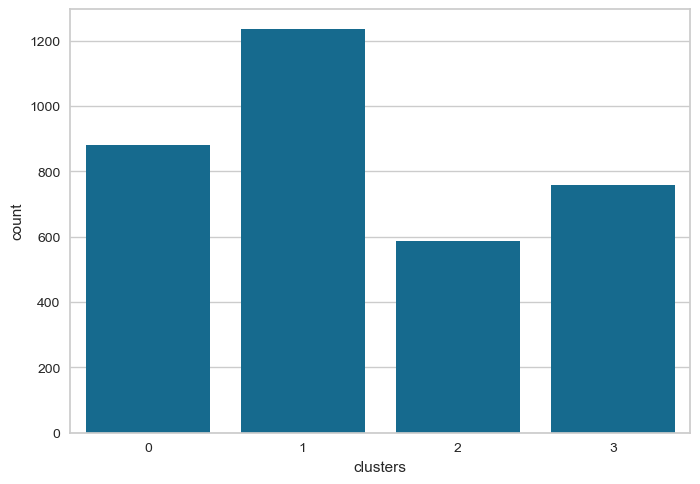

In [26]:
# CARRY PUT SOME VIDUALIZATION ON THE NEW DATA
sns.countplot(x = Tanzaninan_TC_3.clusters)

#### From the visualization above, it clearly shows the Cluster (1) has more data observation been stored, and followed by cluster (0).

<Axes: xlabel='total_cost', ylabel='Count'>

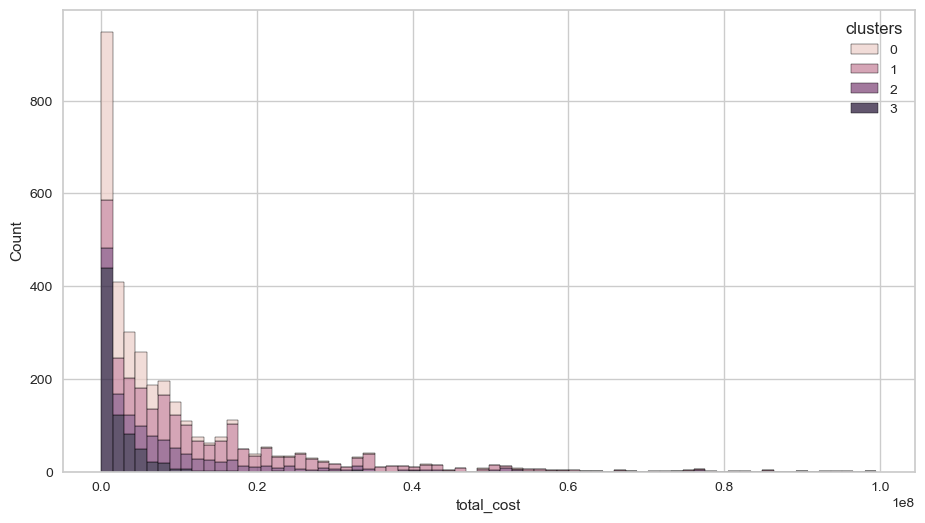

In [27]:
# A Histplot of the clusters
plt.figure(figsize = (11, 6))
sns.histplot(x = 'total_cost', hue = 'clusters', multiple = 'stack', data = Tanzaninan_TC_3)

#### From the visualization above, it clearly shows the Cluster (1) are the top spenders, followed by cluster (2).

<Axes: xlabel='clusters', ylabel='total_cost'>

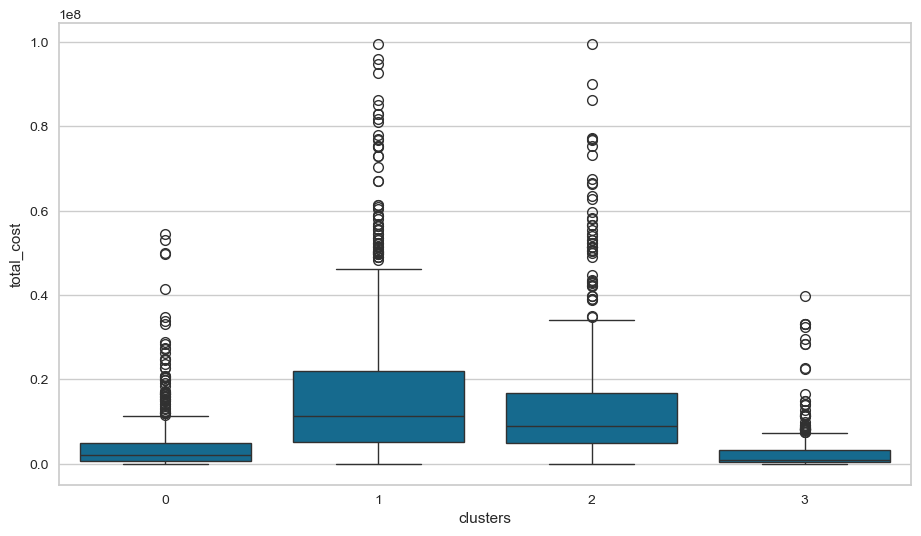

In [28]:
# A boxplot of the clusters
plt.figure(figsize = (11, 6))
sns.boxplot(y = 'total_cost', x = 'clusters', data = Tanzaninan_TC_3)

#### From the visualization above, it clearly shows the Cluster (1) are the top spenders, followed by cluster (2).

<Axes: xlabel='age_group', ylabel='total_cost'>

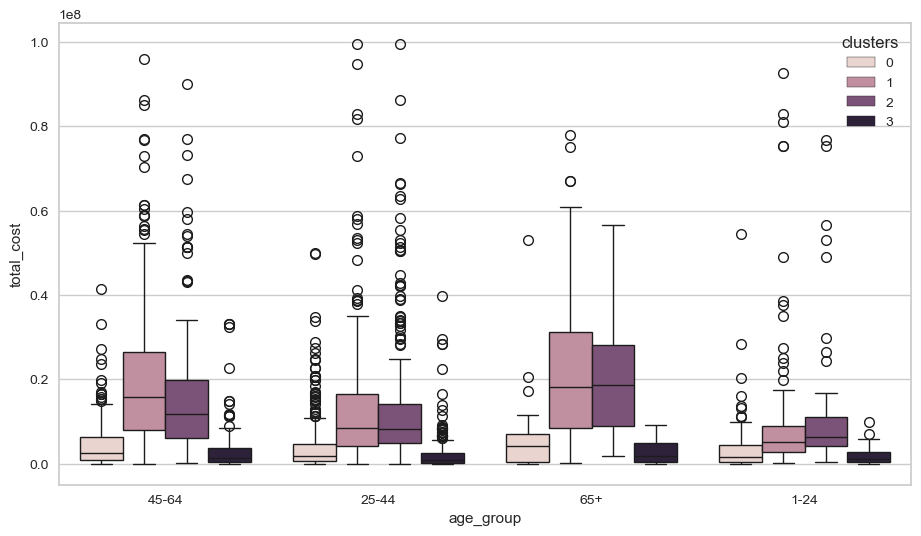

In [30]:
# A boxplot of the clusters
plt.figure(figsize = (11, 6))
sns.boxplot(y = 'total_cost', x = 'age_group', hue = 'clusters', data = Tanzaninan_TC_3)

#### From the visualization above, it clearly shows that tourists who are 65 years and above are the hihgest spenders in the Tanzanian Tourism followed by tourists in the age between 45 and 64 years.

## Results
**Key Spending Insights by Age Group:**

1. **Premium Seniors (65+ years)** - Highest Spenders 🏆
   - Largest tourism expenditure per visitor
   - Longer stays (avg 8.5 nights mainland)
   - Premium package preference with guided tours
   - Target segment for luxury tourism development

2. **Affluent Middle-Aged (45-64 years)** - Second Highest Spenders
   - High spending on accommodation and activities
   - Wildlife tourism primary interest (47% of segment)
   - Mix of independent and package tours
   - Repeat visitor potential (32% return rate)

3. **Active Adults (25-44 years)** - Volume Segment
   - Largest visitor volume (52% of tourists)
   - Moderate spending per capita
   - Adventure and wildlife tourism focus
   - Budget-conscious with selective package purchases

4. **Young Travelers (18-24 years)** - Budget Segment
   - Lowest per-capita spending
   - Independent travel arrangement preference
   - Shorter stays, backpacker profile
   - High social media engagement potential

**Geographic Insights:**
- **Top Source Markets**: USA (695 visitors), followed by European nations
- **105 countries** represented - diverse international appeal
- **67% first-time visitors** - significant repeat visitor conversion opportunity

**Tourism Patterns:**
- **Average spend**: $8.1 million TZS (~$3,400 USD) per visitor
- **Average stay**: 8.5 nights mainland, 2.3 nights Zanzibar
- **Wildlife tourism**: 47% primary activity
- **Leisure focus**: 59% leisure/holiday purpose
- **Payment**: 87% cash transactions (infrastructure gap opportunity)

**Model Performance:**
- **PCA**: Successfully reduced 23 features to 3 dimensions while preserving variance
- **Clustering**: Clear segment separation visible in 3D visualization
- **Actionable segments**: Each cluster shows distinct spending and behavior patterns
